In [ ]:
import neuralforecast as nf
from neuralforecast import NeuralForecast
import logging
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
from neuralforecast.losses.pytorch import MAE
from neuralforecast.auto import AutoGRU, AutoTCN, AutoFEDformer, AutoPatchTST
import pandas as pd
import numpy as np
from sktime.performance_metrics.forecasting import (
    mean_absolute_scaled_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

import matplotlib.pyplot as plt
from sktime.utils.plotting import plot_series

In [55]:
from typing import Optional


def wide_to_long_df(df: pd.DataFrame) -> pd.DataFrame:
    kursy = df[['USD_EUR']]
    kursy = kursy.rename(columns={"USD_EUR": "exo", "DATE": "ds"})
    df = df.drop(columns=['USD_EUR'])
    df = pd.melt(df, ignore_index=False).reset_index(names="date")
    df = df.rename(columns={"variable": "unique_id", "date": "ds", "value": "y"})
    df = df.join(kursy, on='ds')
    return df


def long_to_wide_df(df: pd.DataFrame, values_col: Optional[str] = None) -> pd.DataFrame:
    if "unique_id" not in df.columns:
        df = df.reset_index(names="unique_id")

    values_col = values_col if values_col else df.columns[-1]
    df = pd.pivot(df, columns="unique_id", index="ds", values=values_col)
    return df

In [46]:
df_stocks = pd.read_csv('portfolio_data.csv')
df_btc = df_stocks[['Date','BTC']]
df_btc.index = pd.to_datetime(df_btc['Date'])
df_btc = df_btc.drop(columns=['Date'])

df_kurs = pd.read_csv('USD-EUR.csv')
df_kurs = df_kurs[['Date','Price']]
df_kurs = df_kurs.sort_index(ascending=False)
df_kurs.index = pd.to_datetime(df_kurs['Date'])
df_kurs = df_kurs.drop(columns=['Date'])

df = df_btc.join(df_kurs, how='inner')
df.rename(columns={'BTC':'BTC_Price','Price':'USD_EUR'}, inplace=True)

In [47]:
df_train = df.loc[df.index < '2019-01-01']
df_test = df.loc[df.index >= '2019-01-01']

In [76]:
def evaluate_model(
    model,
    df_train: pd.Series,
    df_test: pd.Series,
    h=20
) -> None:
    

    data_train = wide_to_long_df(df_train)
    data_train['y'].loc[data_train['y'].isna()==True]=0

    data_test = wide_to_long_df(df_test)
    data_test['y'].loc[data_test['y'].isna()==True]=0
    

    model.fit(data_train)
    
    forecasts = model.predict()

    mae = mean_absolute_error(df_test['BTC_Price'][:h], long_to_wide_df(forecasts))
    mase = mean_absolute_scaled_error(df_test['BTC_Price'][:h], long_to_wide_df(forecasts),y_train=df_train['BTC_Price'])

    print(f"MAE: {mae:.2f}")
    print(f"MASE: {mase:.2f}")
    
    return long_to_wide_df(forecasts)

In [77]:
h=14

def config():
    return {
        "hist_exog_list": ['exo']  # Historic exogenous
    }

model = AutoGRU(
    h=h,
    loss=MAE(),
    num_samples=1,
    verbose=False,
    config=config()
)

nf = NeuralForecast(
    models=[model],
    freq="D"
    
)

nf.fit

print("GRU forecaster 14 days horizon:")

gru_forecast = evaluate_model(nf,df_train=df_train,df_test=df_test,h=h)


(_train_tune pid=32268) d:\2studiowanie\sem2\UM\StockPrediction\vpy3-10-0\lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=32268) d:\2studiowanie\sem2\UM\StockPrediction\vpy3-10-0\lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
(_train_tune pid=32268)   warnings.warn(
(_train_tune pid=32268) Seed set to 1
(_train_tune pid=32268) GPU available: False, used: False
(_train_tune pid=32268) TPU available: False, using: 0 TPU cores
(_train_tune pid=32268) 
(_train_tune pid=32268)   | Name         | Type          | Params | Mode  | FLOPs
(_train_tune pid=32268) ---------------------------------------------------------------
(_train_tune pid=32268) 0 | loss         | MAE           | 0      | train | 0    
(_

Epoch 99: 100%|██████████| 1/1 [00:00<00:00,  9.42it/s, v_num=0, train_loss_step=3.100, train_loss_epoch=3.290]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 117.52it/s]
(_train_tune pid=32268) 
Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  8.25it/s, v_num=0, train_loss_step=2.030, train_loss_epoch=2.470, valid_loss=1.77e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  8.57it/s, v_num=0, train_loss_step=1.860, train_loss_epoch=1.390, valid_loss=2.08e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 399: 100%|██████████| 1/1 [00:00<00:00,  8.93it/s, v_num=0, train_loss_step=0.787, train_loss_epoch=0.800, valid_loss=1.94e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 499: 100%|████████

2026-01-22 15:57:45,300	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/Admin/ray_results/_train_tune_2026-01-22_15-55-39' in 0.0080s.
d:\2studiowanie\sem2\UM\StockPrediction\vpy3-10-0\lib\site-packages\neuralforecast\common\_base_model.py:151: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
  warnings.warn(
Seed set to 1


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  8.85it/s, v_num=0, train_loss_step=0.349, train_loss_epoch=0.336, valid_loss=1.75e+3]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  7.89it/s, v_num=0, train_loss_step=0.349, train_loss_epoch=0.349, valid_loss=1.68e+3]


(_train_tune pid=32268) `Trainer.fit` stopped: `max_steps=1000` reached.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

d:\2studiowanie\sem2\UM\StockPrediction\vpy3-10-0\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

MAE: 287.60
MASE: 3.15


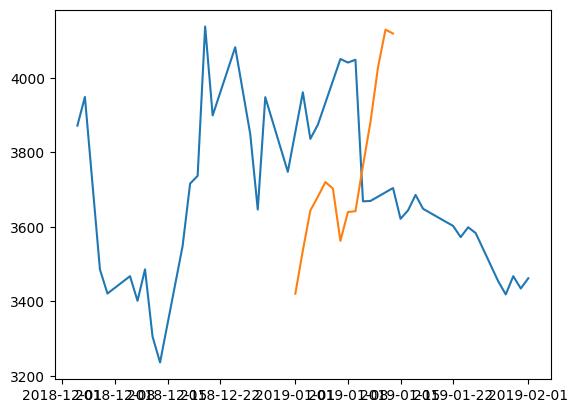

In [92]:
fig = plt.figure()
df_part = df.loc[(df.index >= '2018-12-01') & (df.index <= '2019-02-01')]
plt.plot(df_part.index,df_part['BTC_Price'], label='Actual BTC Price')
plt.plot(gru_forecast.index,gru_forecast, label='pred')
plt.show()

In [89]:
df.loc[(df.index >= '2019-01-01') & (df.index <= '2019-01-14')].index

DatetimeIndex(['2019-01-02', '2019-01-03', '2019-01-04', '2019-01-07',
               '2019-01-08', '2019-01-09', '2019-01-10', '2019-01-11',
               '2019-01-14'],
              dtype='datetime64[ns]', name='Date', freq=None)